In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload CSV file
from google.colab import files
uploaded = files.upload()

# Read dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Display first 5 rows
df.head()

Saving Cleaned_Cafe_Sales.csv to Cleaned_Cafe_Sales.csv


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Weekday
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,8.0,Friday
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,2023.0,5.0,16.0,Tuesday
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,2023.0,7.0,19.0,Wednesday
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27,2023.0,4.0,27.0,Thursday
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,2023.0,6.0,11.0,Sunday


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (10000, 12)

Columns:
Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date', 'Year', 'Month',
       'Day', 'Weekday'],
      dtype='object')

Data Types:
Transaction ID       object
Item                 object
Quantity            float64
Price Per Unit      float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Year                float64
Month               float64
Day                 float64
Weekday              object
dtype: object

Missing Values:
Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
Year                460
Month               460
Day                 460
Weekday             460
dtype: int64


In [6]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Fill missing numeric values with median
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Fill missing categorical values with mode
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Year                0
Month               0
Day                 0
Weekday             0
dtype: int64


/tmp/ipykernel_6424/1386503269.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_6424/1386503269.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [7]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Day,Weekday
count,10000,10000,10000.000000,10000.00000,10000.000000,10000,10000,10000,10000.0,10000.000000,10000.000000,10000
unique,10000,8,NaN,NaN,NaN,3,2,365,NaN,NaN,NaN,7
top,TXN_9226047,Juice,NaN,NaN,NaN,Digital Wallet,Takeaway,2023-02-06,NaN,NaN,NaN,Friday
freq,1,2140,NaN,NaN,NaN,5469,6983,500,NaN,NaN,NaN,1848
mean,NaN,NaN,3.027100,2.95265,8.948150,NaN,NaN,NaN,2023.0,6.545900,15.750700,NaN
std,NaN,NaN,1.384614,1.24396,5.831191,NaN,NaN,NaN,0.0,3.370642,8.557282,NaN
min,NaN,NaN,1.000000,1.00000,1.000000,NaN,NaN,NaN,2023.0,1.000000,1.000000,NaN
25%,NaN,NaN,2.000000,2.00000,4.000000,NaN,NaN,NaN,2023.0,4.000000,8.000000,NaN
50%,NaN,NaN,3.000000,3.00000,8.000000,NaN,NaN,NaN,2023.0,7.000000,16.000000,NaN
75%,NaN,NaN,4.000000,4.00000,12.000000,NaN,NaN,NaN,2023.0,9.000000,23.000000,NaN


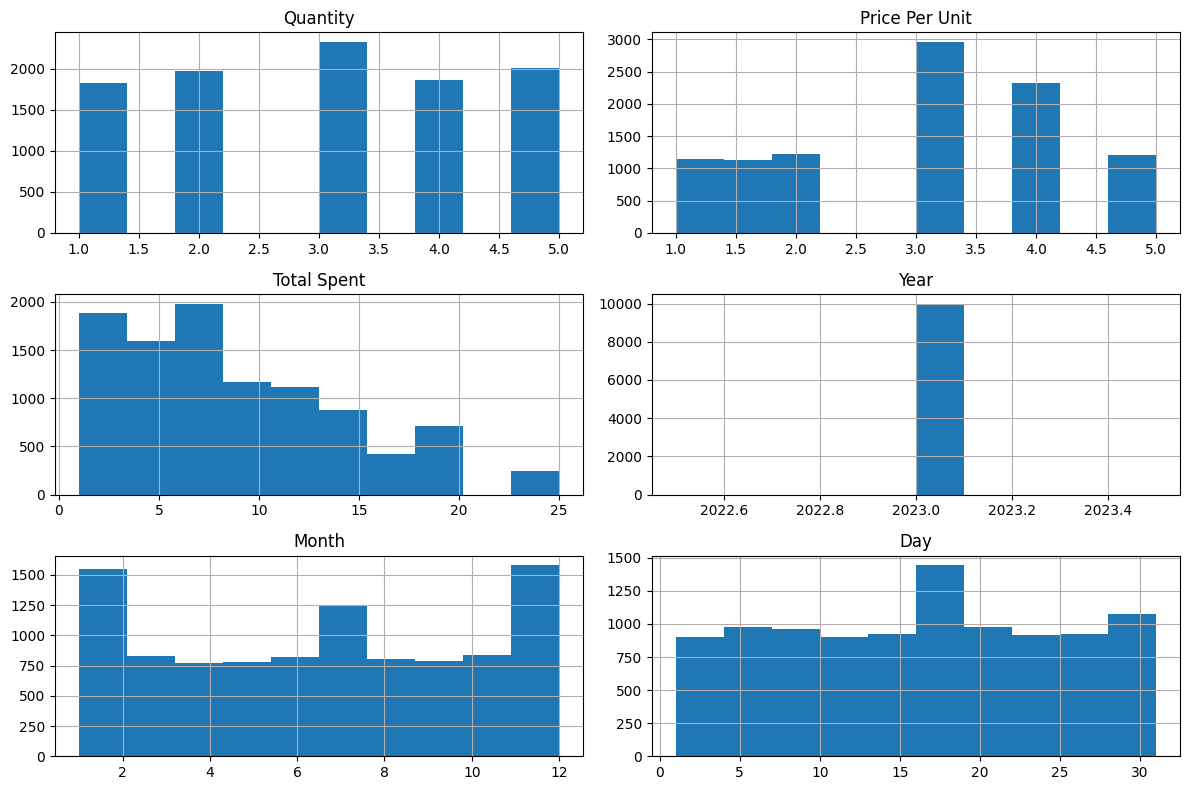

In [8]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

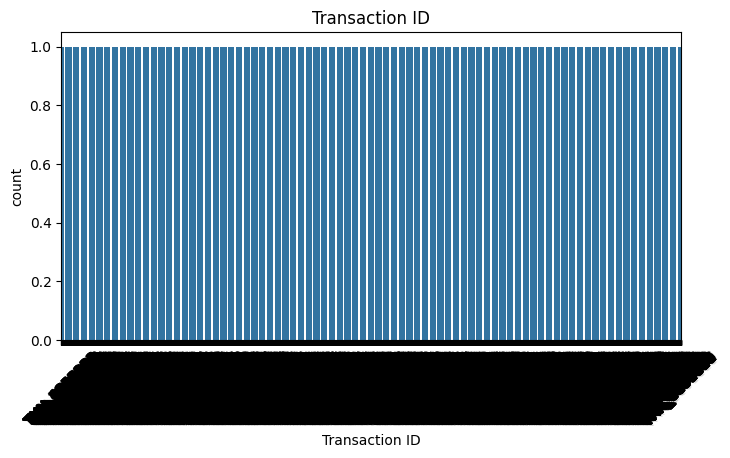

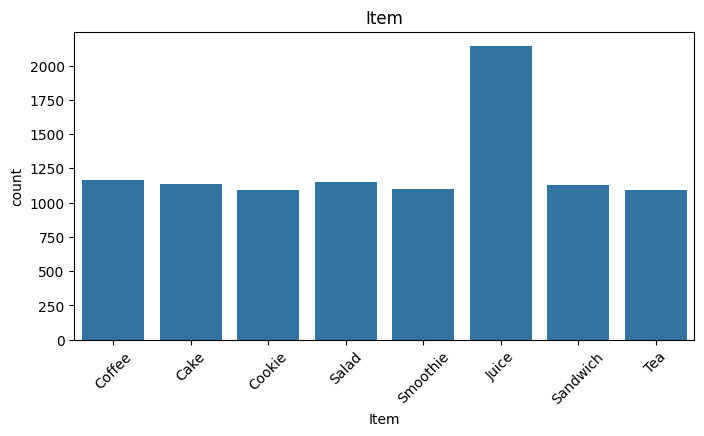

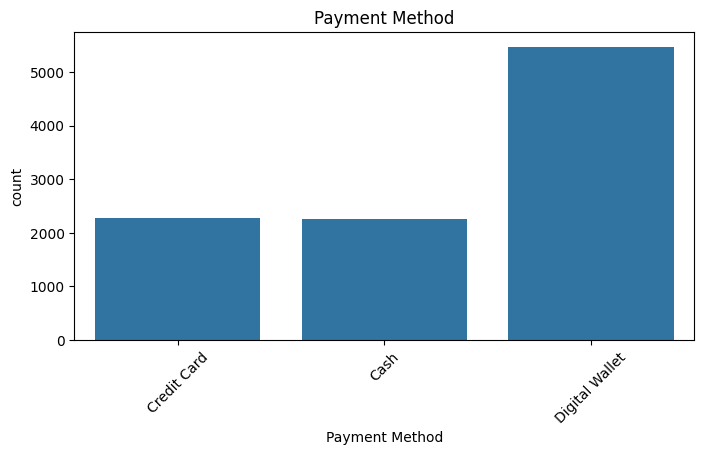

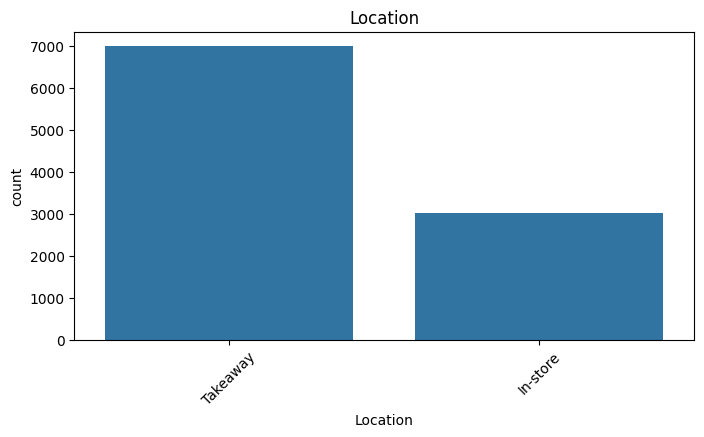

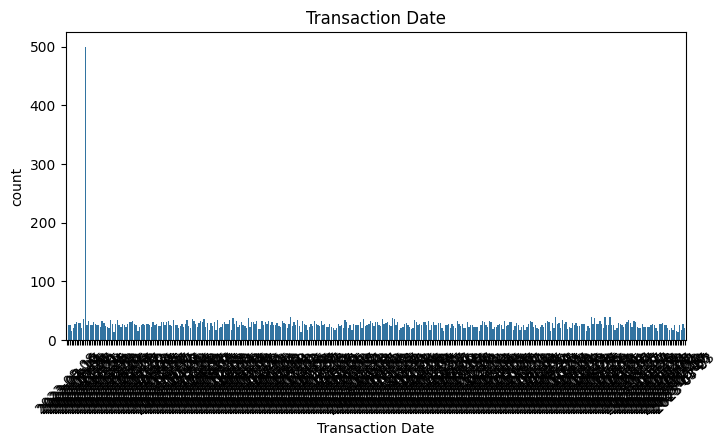

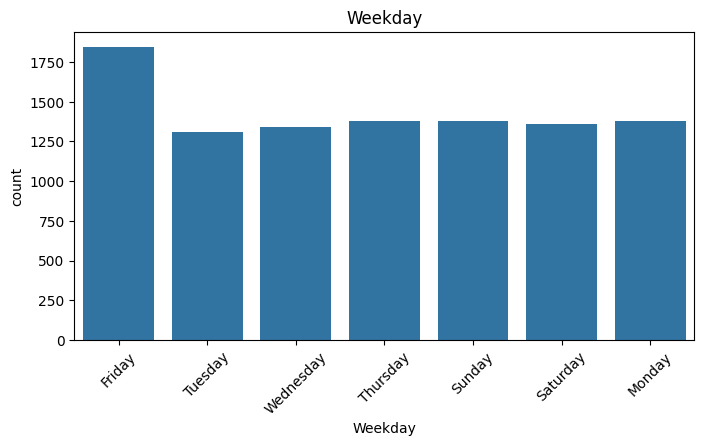

In [9]:
for col in categorical_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

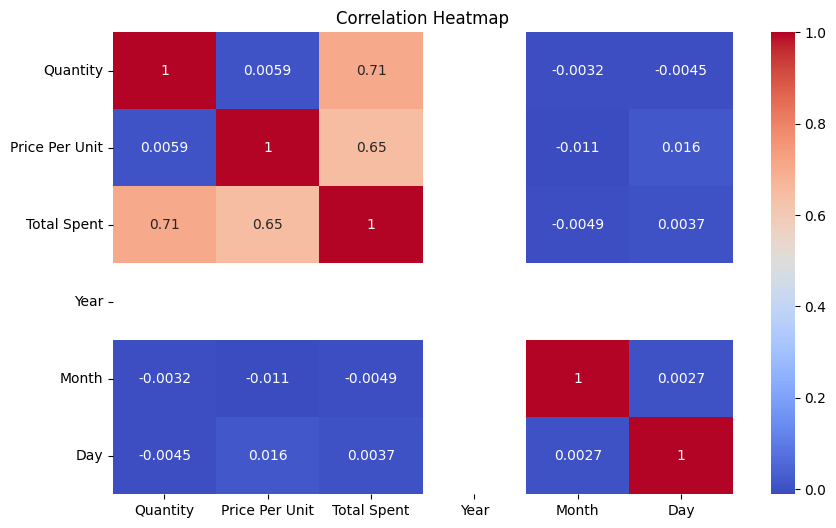

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

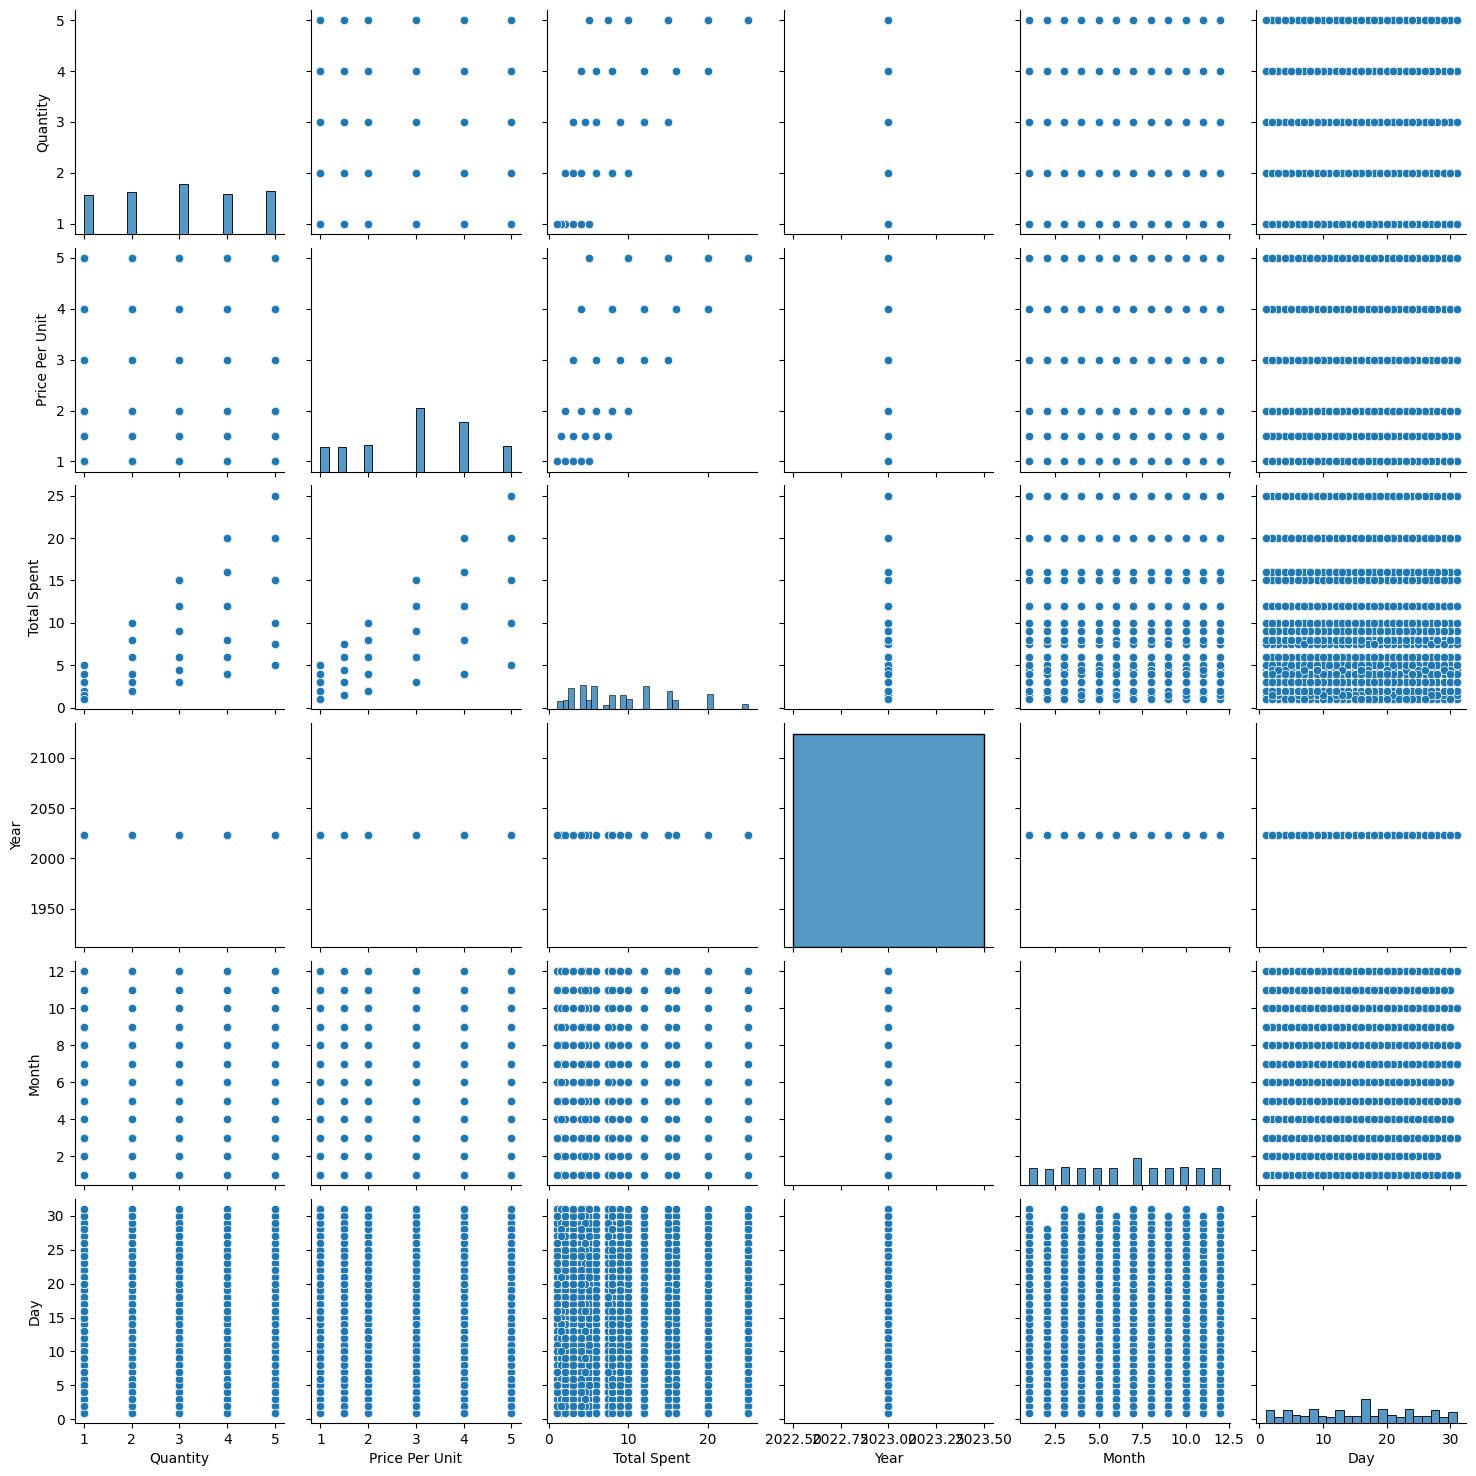

In [11]:
sns.pairplot(df[numeric_cols])
plt.show()

Item
Juice       19157.0
Salad       16959.0
Sandwich    13538.0
Smoothie    13218.0
Cake        10401.0
Name: Total Spent, dtype: float64


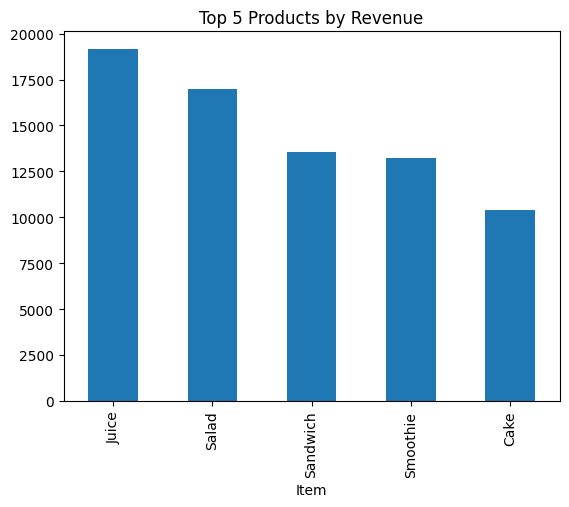

In [12]:
top_products = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False).head(5)

print(top_products)

top_products.plot(kind='bar')
plt.title("Top 5 Products by Revenue")
plt.show()

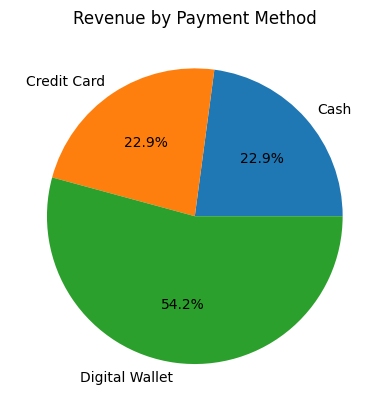

In [13]:
payment_sales = df.groupby('Payment Method')['Total Spent'].sum()

payment_sales.plot(kind='pie', autopct='%1.1f%%')
plt.title("Revenue by Payment Method")
plt.ylabel('')
plt.show()

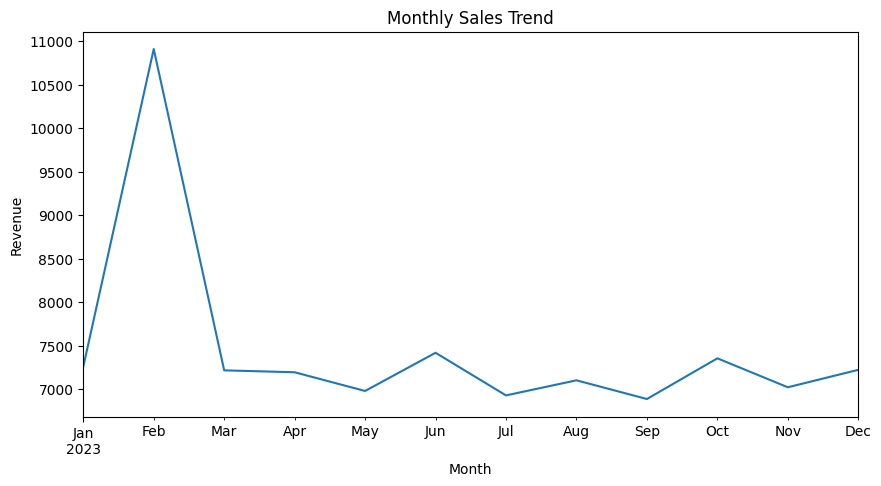

In [14]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

monthly_sales = df.groupby(
    df['Transaction Date'].dt.to_period('M')
)['Total Spent'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [15]:
print("Total Revenue :", df['Total Spent'].sum())
print("Average Order Value :", df['Total Spent'].mean())
print("Total Transactions :", len(df))

Total Revenue : 89481.5
Average Order Value : 8.94815
Total Transactions : 10000
